---
execute:
  skip: true
authors:
- name: Monika Doerig
doi: 10.5281/zenodo.21403392
github: https://github.com/neurodesk/neurodeskedu/blob/main/books/examples/diffusion_imaging/qsirecon.ipynb
edit_url: https://github.com/neurodesk/neurodeskedu/edit/main/books/examples/diffusion_imaging/qsirecon.ipynb
downloads:
- url: /edu/_sources/examples/diffusion_imaging/qsirecon.ipynb
  title: Download source notebook
  filename: qsirecon.ipynb
  static: false
---
# QSIRecon

:::{admonition} Under review
:class: nd-review-badge nd-review-badge--in-progress

[review issue](<https://github.com/neurodesk/neurodeskedu-reviews/issues/61>)
:::

:::{dropdown} Run this notebook
:class: nd-launch

- [Run in Australia](<https://play.neurodesk.cloud.edu.au/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/diffusion_imaging/qsirecon.ipynb&branch=main>)
- [Run in Europe](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/diffusion_imaging/qsirecon.ipynb&branch=main>)
- [Run in America](<https://play-america.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/diffusion_imaging/qsirecon.ipynb&branch=main>)
- [Run in Global Server 1](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/diffusion_imaging/qsirecon.ipynb&branch=main>)
- [Run in Global Server 2](<https://edu.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/diffusion_imaging/qsirecon.ipynb&branch=main>)
:::

## Reconstructing a structural connectome 


**Author:** Monika Doerig

**Date:** 16 July 2026

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

<details style="border-left: 4px solid #f0a500; background-color: rgba(240, 165, 0, 0.08); border-radius: 4px; padding: 0.75em 1em; margin: 1em 0;">
  <summary style="cursor: pointer; display: flex; justify-content: space-between; align-items: center; list-style: none; font-size: 1.1em;">
    <strong style="color: black;">✨ Use of AI</strong>
    <span style="color: black !important; font-size: 1.1em;">▽</span>
  </summary>
  <p style="font-size: 1.1em;">This notebook was drafted with assistance from an LLM (GLM-5.2, via Neurodesk) and then revised by the author. The author reviewed the final content and takes responsibility for it.</p>
</details>

### Citation and Resources:

#### Tools included in this workflow
__QSIRecon:__

- Cieslak, M., Cook, P. A., He, X., Yeh, F. C., Dhollander, T., Adebimpe, A., Aguirre, G. K., Bassett, D. S., Betzel, R. F., Bourque, J., Cabral, L. M., Davatzikos, C., Detre, J. A., Earl, E., Elliott, M. A., Fadnavis, S., Fair, D. A., Foran, W., Fotiadis, P., Garyfallidis, E., … Satterthwaite, T. D. (2021). QSIPrep: an integrative platform for preprocessing and reconstructing diffusion MRI data. Nature methods, 18(7), 775–778. [https://doi.org/10.1038/s41592-021-01185-5](https://doi.org/10.1038/s41592-021-01185-5)

#### Workflows this work is based on
- Chains on the QSIPrep output produced by the [companion QSIPrep notebook](qsiprep.ipynb).

#### Dataset
__OpenNeuro:__
- Hannelore Aerts and Daniele Marinazzo (2018). BTC_preop. [OpenNeuro Dataset ds001226](https://openneuro.org/datasets/ds001226/versions/00001)

__OSF__ Preprocessed data with QSIPrep :
- Dörig, M. (2026, July 14). Diffusion MRI with QSIPrep & QSIRecon: Interactive NeurodeskEDU Examples. Retrieved from [osf.io/q7v8c](https://osf.io/q7v8c/overview)

#### Educational resources
- [QSIRecon documentation](https://qsirecon.readthedocs.io/)


## Load software tools and import python libraries

In [1]:
# Load QSIRecon
import module
await module.load('qsirecon/1.1.0')
await module.list()

['qsirecon/1.1.0']

The base image already provides the common scientific Python packages (see the [Neurodesktop Dockerfile](https://github.com/neurodesk/neurodesktop/blob/main/Dockerfile)). Only a few standard libraries are needed below.

In [2]:
# Import the necessary libraries
import os
import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from bs4 import BeautifulSoup
from IPython.display import HTML, display
import base64
import subprocess

### FreeSurfer license

In [3]:
# Request a freesurfer license from https://surfer.nmr.mgh.harvard.edu/registration.html
# and store it in your homedirectory 
# This is just an exampe - please replace with your license id:
!echo "Steffen.Bollmann@cai.uq.edu.au" > ~/.license
!echo "21029" >> ~/.license
!echo "*Cqyn12sqTCxo" >> ~/.license
!echo "FSxgcvGkNR59Y" >> ~/.license

## Introduction

QSIRecon is the post-processing companion to QSIPrep (it does for diffusion MRI what [XCP-D](https://xcp-d.readthedocs.io/) does for BOLD). Where QSIPrep stops at preprocessed data, QSIRecon builds the workflows that turn it into many of the biologically interesting derivatives you actually test hypotheses on: ODF/FOD reconstruction, model fits and parameter estimates, tractography, tractometry, regional connectivity, and tabular outputs.

Its aim is to make state-of-the-art methods from [DIPY](https://dipy.org/), [MRtrix3](https://www.mrtrix.org/), [DSI Studio](https://dsi-studio.labsolver.org/), [PyAFQ](https://yeatmanlab.github.io/pyAFQ/) and other packages straightforward to apply to preprocessed dMRI. Rather than one fixed pipeline, QSIRecon offers a set of curated reconstruction workflows, selected at runtime.

This notebook runs one of them: an MRtrix3 multi-shell pipeline using MSMT-CSD to estimate fibre orientation distributions, iFOD2 probabilistic tractography to generate streamlines, and SIFT2 to weight them — producing a structural connectome, which we inspect in the QSIRecon visual report.

### Learning objectives
This notebook assumes a basic understanding of diffusion MRI and familiarity with QSIPrep's role in preprocessing (see the companion QSIPrep notebook). By the end you will be able to:
- Describe what QSIRecon does and how it relates to QSIPrep
- Select and run a QSIRecon reconstruction workflow on QSIPrep derivatives
- Inspect the resulting FOD, tractography and connectome outputs in the QSIRecon visual report

## Data Preparation
QSIRecon consumes QSIPrep derivatives. We download a copy of the output from the [QSIPrep notebook](qsiprep.ipynb) from OSF, so this notebook can be run on its own.

In [4]:
def fetch_if_missing(remote, local):
    """Fetch from OSF, downloading to a temp name so a partial file never
    looks like a complete one on rerun."""
    if os.path.exists(local):
        print(f"Already exists, skipping download: {local}")
        return
    tmp = local + ".part"
    subprocess.run(["osf", "-p", "q7v8c", "fetch", remote, tmp], check=True)
    os.replace(tmp, local)
    print(f"Downloaded: {local}")

fetch_if_missing("qsiprep/qsiprep-CON01.tar.gz", "qsiprep-CON01.tar.gz")

if os.path.exists("qsiprep-output/sub-CON01"):
    print("Already extracted, skipping: qsiprep-output/sub-CON01")
else:
    os.makedirs("qsiprep-output", exist_ok=True)
    subprocess.run(["tar", "xzf", "qsiprep-CON01.tar.gz", "-C", "qsiprep-output"], check=True)
    print("Extracted QSIPrep derivatives to qsiprep-output/")

if os.path.exists("qsiprep-CON01.tar.gz"):
    os.remove("qsiprep-CON01.tar.gz")
    print("Removed tarball to save disk")

  6%|▌         | 26.0M/453M [00:00<00:03, 134Mbytes/s]

 13%|█▎        | 58.0M/453M [00:00<00:03, 129Mbytes/s]

 18%|█▊        | 82.7M/453M [00:00<00:03, 104Mbytes/s]

 24%|██▍       | 108M/453M [00:00<00:03, 101Mbytes/s]  

 29%|██▊       | 130M/453M [00:01<00:03, 92.6Mbytes/s]

...

 88%|████████▊ | 397M/453M [00:03<00:00, 157Mbytes/s]

 96%|█████████▌| 433M/453M [00:03<00:00, 147Mbytes/s]

100%|██████████| 453M/453M [00:03<00:00, 130Mbytes/s]


Downloaded: qsiprep-CON01.tar.gz


Extracted QSIPrep derivatives to qsiprep-output/
Removed tarball to save disk


## Analysis

We run QSIRecon on the QSIPrep derivatives using the `mrtrix_multishell_msmt_noACT` reconstruction spec — an MRtrix3 multishell pipeline using MSMT-CSD for FOD estimation, iFOD2 probabilistic tractography, SIFT2 streamline weighting, and `tck2connectome` to produce a structural connectome.

As the name suggests, this spec does not use anatomically constrained tractography (ACT). The alternative `mrtrix_multishell_msmt_ACT-hsvs` spec constrains tractography using a hybrid surface-volume segmentation, but that requires FreeSurfer derivatives passed via `--fs-subjects-dir`, which our QSIPrep 1.0.1 run from the companion [notebook](qsiprep.ipynb) doesn't produce — FreeSurfer would have to be run separately. The `mrtrix_multishell_msmt_ACT-fast` variant substitutes FSL FAST for the segmentation, but the QSIRecon documentation does not recommend it. So we use the non-ACT spec here.

### Customising the spec
Reconstruction workflows are defined in YAML files, and `--recon-spec` accepts either a
built-in name or a path to your own file. The built-in specs are a good starting point for
[customisation](https://qsirecon.readthedocs.io/en/latest/building_workflows.html#building-workflows) — so rather than invoking `mrtrix_multishell_msmt_noACT` by name, we download it and reduce `tckgen`'s `select` parameter from 10 million streamlines to 200,000.

This is purely to keep the notebook runnable in reasonable time and disk: streamline count drives most of the cost of tractography. A research analysis would use the full count. Note the YAML is fetched at a pinned commit (af43da9), which is the commit the QSIRecon version in this container was built from — so the spec we edit matches the built-in one.

:::{admonition} Long-running
:class: warning
Even at a reduced streamline count, tractography plus SIFT2 is compute-heavy — expect this cell to take a while depending on available resources.
:::

Let's look at the command-line arguments first and then run `qsirecon`:

In [5]:
!qsirecon --help

usage: qsirecon [-h]
                [--participant-label PARTICIPANT_LABEL [PARTICIPANT_LABEL ...]]
                [--session-id SESSION_ID [SESSION_ID ...]]
                [-d PACKAGE=PATH [PACKAGE=PATH ...]] [--bids-filter-file FILE]
                [--bids-database-dir PATH] [--nprocs NPROCS]
                [--omp-nthreads OMP_NTHREADS] [--mem MEMORY_MB] [--low-mem]
                [--use-plugin FILE] [--sloppy] [--boilerplate-only]
                [--reports-only]
                [--report-output-level {root,subject,session}] [--infant]
                [--b0-threshold B0_THRESHOLD]
                [--output-resolution OUTPUT_RESOLUTION]
                [--fs-license-file PATH] [--recon-spec RECON_SPEC]
                [--input-type {qsiprep,ukb,hcpya}] [--fs-subjects-dir PATH]
                [--skip-odf-reports] [--atlases ATLAS [ATLAS ...]] [--version]
                [-v] [-w WORK_DIR] [--resource-monitor] [--config-file FILE]
                [--write-graph] [--stop-on-first

Now we'll customise the spec file and reduce the streamlines to 200,000:

In [6]:
%%bash
set -e -u -o pipefail

curl -fsSL -o recon_spec_ci.yaml \
  https://raw.githubusercontent.com/PennLINC/qsirecon/af43da9/qsirecon/data/pipelines/mrtrix_multishell_msmt_noACT.yaml

sed -i -E 's/^([[:space:]]*select:).*/\1 200000/' recon_spec_ci.yaml
grep -q 'select: 200000' recon_spec_ci.yaml || { echo "sed did not match — spec unchanged"; exit 1; }

cat recon_spec_ci.yaml

anatomical: []
name: mrtrix_multishell_msmt_noACT
nodes:
-   action: csd
    input: qsirecon
    nam

e: msmt_csd
    parameters:
        fod:
            algorithm: msmt_csd
            max_sh:
       

     - 8
            - 8
            - 8
        mtnormalize: true
        response:
            alg

orithm: dhollander
    qsirecon_suffix: MRtrix3_act-None
    software: MRTrix3
-   action: tractogra

phy
    input: msmt_csd
    name: track_ifod2
    parameters:
        sift2: {}
        tckgen:
    

...

2_count
            scale_invnodevol: false
            search_radius: 2
            stat_edge: sum


            symmetric: true
            use_sift_weights: false
            zero_diagonal: false
   

     -   measure: sift_radius2_count
            scale_invnodevol: false
            search_radius: 

2
            stat_edge: sum
            symmetric: true
            use_sift_weights: true
        

    zero_diagonal: false
    qsirecon_suffix: MRtrix3_act-None
    software: MRTrix3
space: T1w


In [7]:
%%bash
set -e -u -o pipefail
# ensure subjects dir exists at startup
export SUBJECTS_DIR="$HOME/qsiprep-freesurfer-dir"
export APPTAINERENV_SUBJECTS_DIR=$SUBJECTS_DIR
export ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS=1
mkdir -p "$SUBJECTS_DIR"

N_CPUS=$(nproc); N_CPUS=$(( N_CPUS > 12 ? 12 : N_CPUS ))
MEM_MB=$(awk '/MemTotal/ {printf "%d", $2/1024}' /proc/meminfo)
QSIRECON_MEM=$(( MEM_MB * 75 / 100 ))
OMP_THREADS=$(( N_CPUS >= 8 ? 4 : 2 ))

qsirecon qsiprep-output qsirecon-output participant \
    --participant-label CON01 \
    --recon-spec recon_spec_ci.yaml \
    --fs-license-file ~/.license \
    --atlases AAL116 \
    -w qsirecon-work \
    --nthreads "${N_CPUS}" --omp-nthreads "${OMP_THREADS}" --mem-mb "${QSIRECON_MEM}" \
    2>&1 | tee qsirecon.log

260928-23:49:02,709 nipype.workflow IMPORTANT:
	 Running QSIRecon version 1.1.1.dev0+gaf43da9.d20250

414

         License NOTICE ##################################################
         QSIRecon 1.

1.1.dev0+gaf43da9.d20250414
         Copyright The PennLINC Developers.
         
         This prod

uct includes software developed by
         the NiPreps Community (https://nipreps.org/).
         


         Portions of this software were developed at the Department of
         Psychology at Stanfo

...

clude the boilerplate text found in <OUTPUT_PATH>/logs/CITATION.md.


260929-00:16:22,63 nipype.utils WARNING:
	 DatasetType key not in /home/jovyan/workspace/books/examp

les/diffusion_imaging/qsiprep-output/dataset_description.json. Assuming 'derivative'.


260929-00:16:23,126 nipype.utils WARNING:
	 DatasetType key not in /home/jovyan/workspace/books/exam

ples/diffusion_imaging/qsiprep-output/dataset_description.json. Assuming 'derivative'.


In [8]:
#remove the working dir
shutil.rmtree("qsirecon-work", ignore_errors=True)

#### QSIRecon outputs
The reconstruction results are nested under `derivatives/qsirecon-MRtrix3_act-None/` rather than sitting at the top level. The directory name comes from the `qsirecon_suffix` declared in the recon spec — a single run can emit several such datasets, so each is written as its own self-contained BIDS derivatives dataset, with `act-None` recording that we used the non-ACT variant.

Inside, `sub-CON01/ses-preop/dwi/` holds the reconstruction proper: per-tissue FODs from MSMT-CSD (`model-msmtcsd_param-fod_label-{WM,GM,CSF}`, with the matching response functions as `.txt`), the mtnormalise outputs, the iFOD2 streamlines (`model-ifod2_streamlines.tck.gz`), the SIFT2 weights and proportionality coefficient (`model-sift2_streamlineweights.csv`, `model-sift2_mu.txt`), and the connectome itself in `connectivity.mat`. The `figures/` directory holds the panels  shown in the visual report, and `sub-CON01_ses-preop.html` is that report.

At the top level, `atlases/` contains the AAL116 atlas as passed to `--atlases`, while the top-level `sub-CON01/ses-preop/dwi/` holds it resampled into the subject's ACPC space — the parcellation actually used to build the connectome.

In [9]:
! tree qsirecon-output/

qsirecon-output/
├── atlases
│   ├── atlas-AAL116
│   │   ├── atlas-AAL116_dseg.tsv
│   │   ├── atlas-AAL116_space-MNI152NLin2009cAsym_res-01_dseg.json
│   │   └── atlas-AAL116_space-MNI152NLin2009cAsym_res-01_dseg.nii.gz
│   └── dataset_description.json
├── dataset_description.json
├── derivatives
│   └── qsirecon-MRtrix3_act-None
│       ├── dataset_description.json
│       ├── logs
│       │   ├── CITATION.bib
│       │   ├── CITATION.html
│       │   ├── CITATION.md
│       │   └── CITATION.tex
│       ├── sub-CON01
│       │   └── ses-preop
│       │       ├── dwi
│       │       │   ├── sub-CON01_ses-preop_acq-AP_space-ACPC_connectivity.mat
│       │       │   ├── sub-CON01_ses-preop_acq-AP_space-ACPC_exemplarbundles.zip
│       │       │   ├── sub-CON01_ses-preop_acq-AP_space-ACPC_model-ifod2_streamlines.tck.gz
│       │       │   ├── sub-CON01_ses-preop_acq-AP_space-ACPC_model-msmtcsd_param-fod_label-CSF_dwimap.mif.gz
│       │       │   ├── sub-CON01_ses-preop_acq-AP_space-ACP

## Results
We display the full QSIRecon visual report. It contains FOD peak/ODF visualisations and the connectome matrices figure, alongside run provenance and summary sections. The report references its figures as separate files, so we inline them (PNGs as base64, SVGs embedded directly) to make it render in the notebook.

In [10]:
# Display the QSIRecon HTML report with all images inlined.
# PNGs are base64-encoded; SVGs are embedded directly into the DOM.
def display_report(report_path):
    report_dir = os.path.dirname(report_path)
    with open(report_path) as f:
        soup = BeautifulSoup(f, 'html.parser')
    # Inline <img src=...> tags: PNG as base64, SVG embedded directly
    for img in soup.find_all('img'):
        src = img.get('src', '')
        if not src:
            continue
        img_path = os.path.join(report_dir, src.lstrip('./'))
        if os.path.exists(img_path):
            if src.endswith('.svg'):
                with open(img_path) as f:
                    svg_soup = BeautifulSoup(f.read(), 'html.parser')
                    svg_tag = svg_soup.find('svg')
                    if svg_tag:
                        img.replace_with(svg_tag)
            elif src.endswith('.png'):
                with open(img_path, 'rb') as f:
                    data = base64.b64encode(f.read()).decode()
                img['src'] = f'data:image/png;base64,{data}'
    # Also inline SVGs referenced in <a href> tags
    for tag in soup.find_all(href=lambda h: h and h.endswith('.svg')):
        svg_path = os.path.join(report_dir, tag['href'])
        if os.path.exists(svg_path):
            with open(svg_path) as f:
                svg_soup = BeautifulSoup(f.read(), 'html.parser')
                tag.replace_with(svg_soup)
    # Remove nav/button clutter
    for tag in soup(['button', 'nav', 'head']):
        tag.decompose()
    display(HTML(str(soup)))


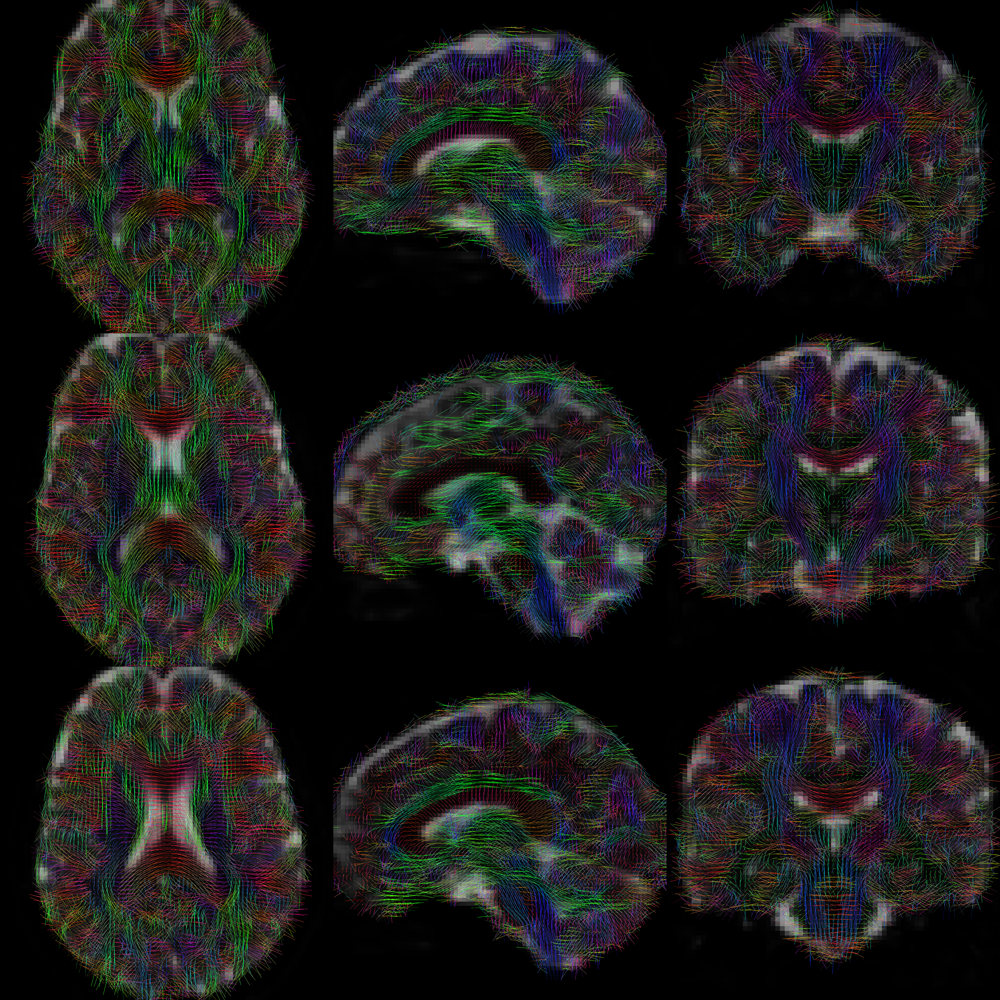
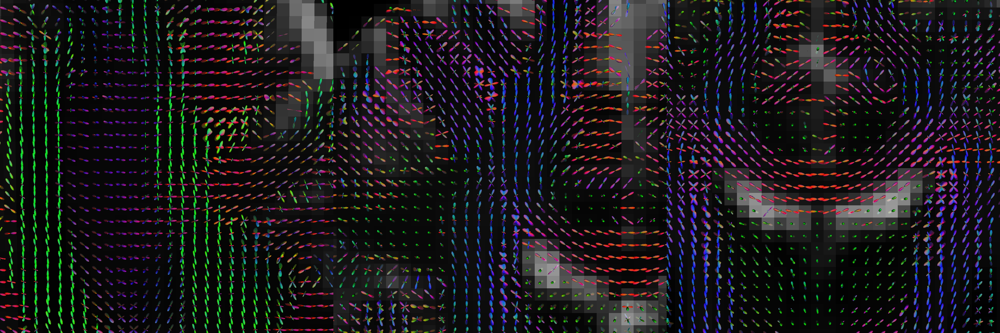

In [11]:
display_report('./qsirecon-output/derivatives/qsirecon-MRtrix3_act-None/sub-CON01_ses-preop.html')

## Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [12]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-09-29T00:16:24.569501+00:00

Python implementation: CPython
Python version       : 3.13.14
IPython version      : 9.12.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 6.8.0-111-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit

IPython   : 9.12.0
bs4       : 4.15.0
matplotlib: 3.11.0
numpy     : 2.5.1

Neurodesktop version: 2026-07-11
